## 1. Úvodní vizualizace dat

Před spuštěním samotných shlukovacích algoritmů je klíčové provést vizuální analýzu distribuce dat v 2D prostoru. 

Načteno 3278 bodů ve 2D prostoru.


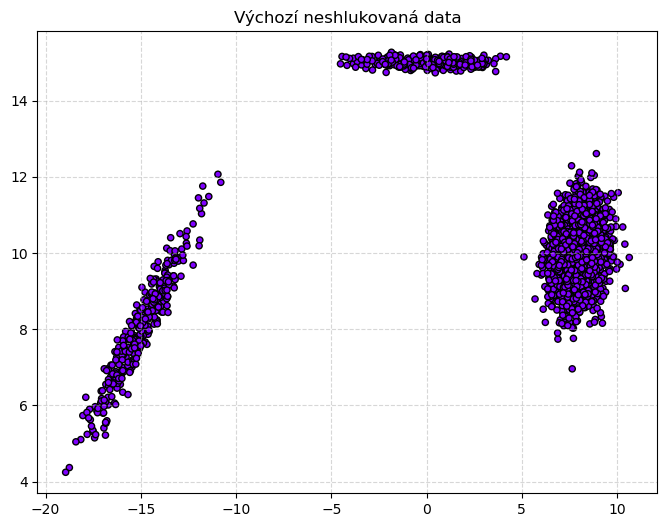

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import tvých vlastních modulů
from generic import load_data, plot_clusters
import clustering as cl

# Načtení dat ze souboru (změň cestu k souboru podle potřeby)
raw_data = load_data("data_shl.txt")

# Převod na numpy array: pro shlukování nás zajímají pouze první 2 sloupce (x, y)
X = np.array([[row[0], row[1]] for row in raw_data], dtype=np.float32)
# Původní třídy (pokud je chceme pro srovnání)
y_true = np.array([row[2] for row in raw_data])

print(f"Načteno {len(X)} bodů ve 2D prostoru.")

# Vykreslení výchozích (neoznačených) dat
plot_clusters(X, np.zeros(len(X)), "Výchozí neshlukovaná data")

Z grafu **"Výchozí neshlukovaná data"** je zřejmé, že datová sada obsahuje tři velmi dobře oddělené a geometricky odlišné shluky (třídy):
1. **Levý shluk:** Podlouhlý, lineárně orientovaný shluk s výraznou vnitřní korelací (skloněný pod úhlem cca 45°).
2. **Horní shluk:** Velmi hustý, horizontálně protáhlý shluk s minimální vertikální variabilitou.
3. **Pravý shluk:** Hustý, vertikálně orientovaný shluk s přibližně gaussovskou distribucí.

Vzhledem k tomu, že mezi shluky je velký prázdný prostor (high-contrast boundary), lze očekávat, že algoritmy pro odhad počtu shluků i samotné dělicí algoritmy budou vykazovat vysokou úspěšnost a stabilitu.

## 2. Detekce a odhad počtu shluků

Cílem této části je automaticky identifikovat přirozený počet shluků $K$ v datech, aniž bychom tuto informaci dopředu zadávali. Porovnáváme tři různé přístupy.

In [2]:
print("--- Odhad počtu shluků ---")

# 1. Metoda shlukové hladiny
k_level, _, _, _ = cl.clustering_level(X)
print(f"Metoda shlukové hladiny odhaduje: {k_level} shluků")

# 2. Metoda řetězové mapy
k_chain, _, _ = cl.chain_map(X)
print(f"Metoda řetězové mapy odhaduje:  {k_chain} shluků")

# 3. Metoda MAXIMIN
# q a start_node můžeš interaktivně měnit
k_maximin, _ = cl.maximin(X, q=0.5, start_node=0)
print(f"Metoda MAXIMIN odhaduje:        {k_maximin} shluků")

# Pro další fázi dělení si zvolíme jeden z odhadů (např. k_level)
K_TARGET = k_level
print(f"\nPro dělení dat do shluků budeme dále pracovat s K = {K_TARGET}")

--- Odhad počtu shluků ---
Metoda shlukové hladiny odhaduje: 3 shluků
Metoda řetězové mapy odhaduje:  3 shluků
Metoda MAXIMIN odhaduje:        3 shluků

Pro dělení dat do shluků budeme dále pracovat s K = 3


### A. Metoda shlukových hladin (Hierarchické shlukování)
Metoda shlukových hladin postupně spojuje nejbližší objekty. 

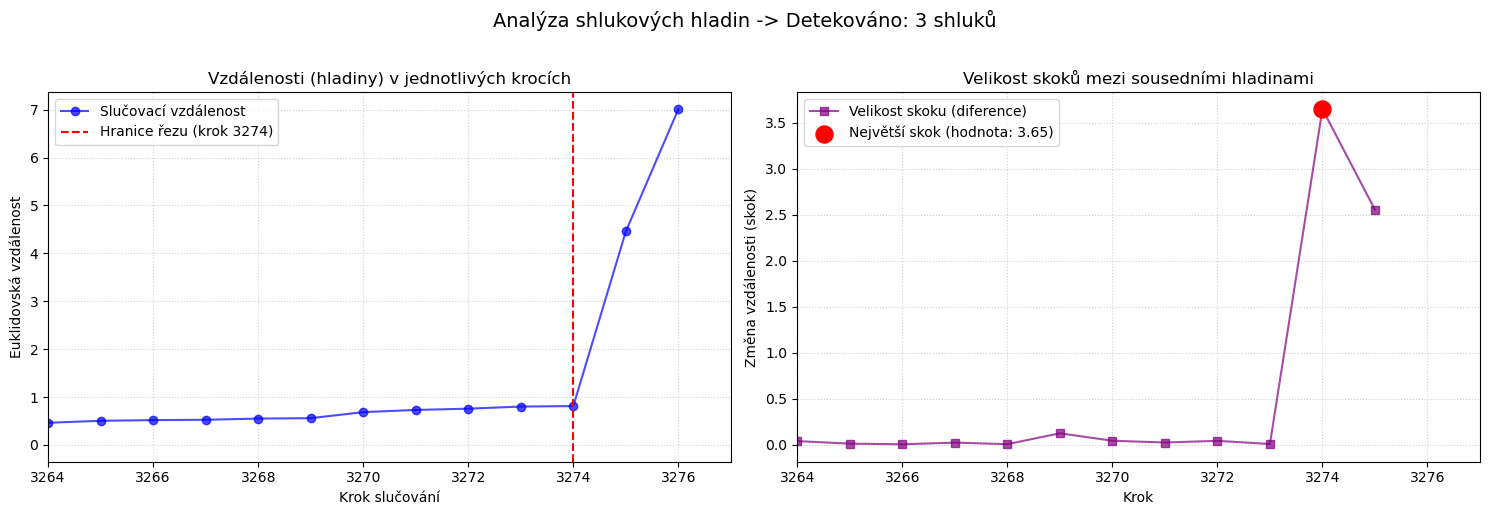

In [3]:
# Analýza Shlukových hladin
n_clusters, dists, jumps, cut_idx = cl.clustering_level(X)

# Vytvoříme dva grafy vedle sebe pro přehledné srovnání
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- GRAF 1: Vzdálenosti při slučování (Hladiny) ---
ax1.plot(dists, marker='o', color='blue', alpha=0.7, label='Slučovací vzdálenost')
# Červená čára značí krok, po kterém už bychom neměli slučovat
ax1.axvline(x=cut_idx, color='red', linestyle='--', label=f'Hranice řezu (krok {cut_idx})')
ax1.set_title("Vzdálenosti (hladiny) v jednotlivých krocích")
ax1.set_xlabel("Krok slučování")
ax1.set_ylabel("Euklidovská vzdálenost")
ax1.legend()
ax1.set_xlim(cut_idx-10, len(dists))
ax1.grid(True, linestyle=":", alpha=0.6)

# --- GRAF 2: Skoky mezi hladinami (Derivace) ---
ax2.plot(jumps, marker='s', color='purple', alpha=0.7, label='Velikost skoku (diference)')
# Zvýrazníme největší skok, který rozhoduje o počtu shluků
ax2.scatter(cut_idx, jumps[cut_idx], color='red', s=150, zorder=5, 
            label=f'Největší skok (hodnota: {jumps[cut_idx]:.2f})')
ax2.set_title("Velikost skoků mezi sousedními hladinami")
ax2.set_xlabel("Krok")
ax2.set_ylabel("Změna vzdálenosti (skok)")
ax2.legend()
ax2.set_xlim(cut_idx-10, len(dists))
ax2.grid(True, linestyle=":", alpha=0.6)

plt.suptitle(f"Analýza shlukových hladin -> Detekováno: {n_clusters} shluků", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

* **Levý graf (Vzdálenosti):** Zobrazuje nárůst euklidovské vzdálenosti při postupném slučování. Až do kroku 3274 (při celkovém počtu bodů $N \approx 3277$) jsou vzdálenosti velmi nízké ($< 1.0$), což odpovídá spojování bodů uvnitř přirozených shluků.
* **Pravý graf (Skoky):** Zobrazuje diference (skoky) mezi sousedními hladinami. Největší skok o hodnotě **3.65** nastává v kroku 3274. Tento skok představuje moment, kdy algoritmus musel spojit dva již hotové velké shluky přes prázdný prostor.
* **Závěr:** Zastavením algoritmu před tímto kritickým skokem získáváme přesně $3277 - 3274 = 3$ shluky.

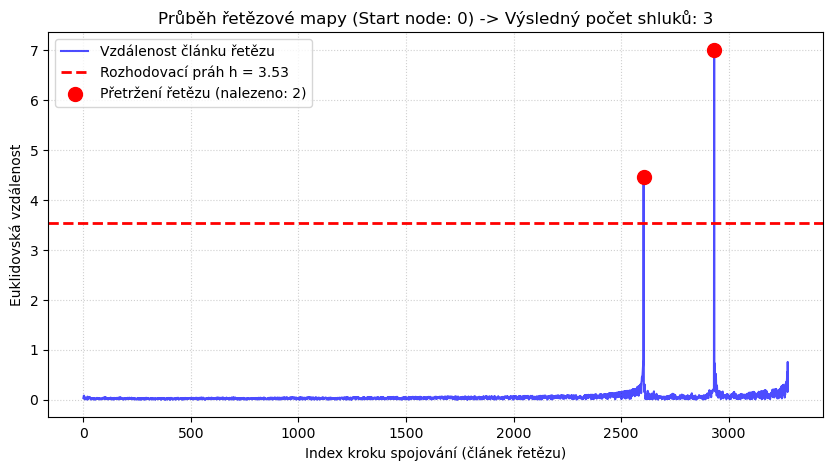

In [4]:
# Analýza Řetězové mapy
start_node = 0  # Můžeš zkusit změnit
n_clusters, dists, h = cl.chain_map(X, start_node=start_node)

plt.figure(figsize=(10, 5))
plt.plot(dists, label="Vzdálenost článku řetězu", color="blue", alpha=0.7)

# Vykreslení rozhodovací hranice H
plt.axhline(y=h, color="red", linestyle="--", linewidth=2, label=f"Rozhodovací práh h = {h:.2f}")

# Zvýraznění bodů, kde se řetězec přetrhl (vzdálenost > h)
break_indices = np.where(dists > h)[0]
plt.scatter(break_indices, dists[break_indices], color="red", s=100, zorder=5, 
            label=f"Přetržení řetězu (nalezeno: {len(break_indices)})")

plt.title(f"Průběh řetězové mapy (Start node: {start_node}) -> Výsledný počet shluků: {n_clusters}")
plt.xlabel("Index kroku spojování (článek řetězu)")
plt.ylabel("Euklidovská vzdálenost")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

* Graf ukazuje sekvenci vzdáleností jednotlivých článků řetězu. Naprostá většina spojení leží hluboko pod hodnotou $1.0$.
* Naopak se zde objevují dva extrémní vrcholy (první okolo indexu 2600 s hodnotou $\approx 4.5$ a druhý okolo indexu 2950 s hodnotou $\approx 7.0$). Tyto špičky představují "přeskoky" řetězce z jednoho izolovaného shluku do druhého.
* Námi definovaná rozhodovací hranice $h = 3.53$ tyto dva skoky úspěšně zachytila. Výsledný počet přetržení řetězu je 2, což odpovídá **3 výsledným shlukům**.

### C. Metoda MAXIMIN (Citlivost na parametry)
Metoda MAXIMIN je heuristický přístup, který hledá reprezentativní středy shluků. Její chování je vysoce závislé na parametru $q$ a počátečním bodu.

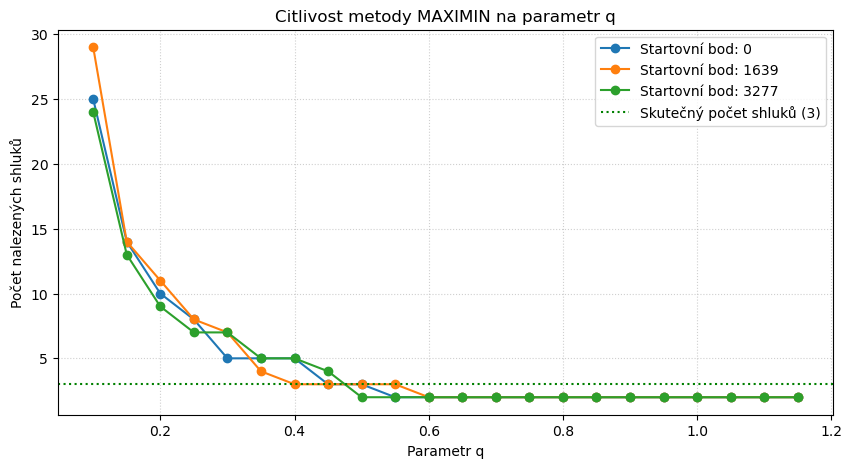

In [15]:
# Analýza citlivosti MAXIMIN
q_values = np.arange(0.1, 1.2, 0.05, dtype=np.float32)
starting_nodes = [0, len(X)//2, len(X)-1] # Tři různé počáteční body

plt.figure(figsize=(10, 5))

for start in starting_nodes:
    cluster_counts = []
    for q in q_values:
        n_clusters, _ = cl.maximin(X, q=q, start_node=start)
        cluster_counts.append(n_clusters)
    plt.plot(q_values, cluster_counts, marker='o', label=f"Startovní bod: {start}")

plt.title("Citlivost metody MAXIMIN na parametr q")
plt.xlabel("Parametr q")
plt.ylabel("Počet nalezených shluků")
plt.axhline(y=3, color="green", linestyle=":", label="Skutečný počet shluků (3)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

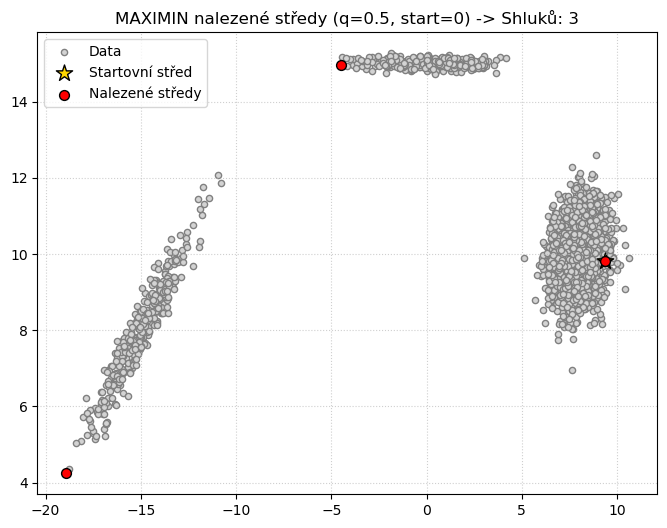

In [16]:
# Vykreslení středů z metody MAXIMIN
q_test = 0.5
start_test = 0

n_clusters, center_indices = cl.maximin(X, q=q_test, start_node=start_test)
centers = X[center_indices]

plt.figure(figsize=(8, 6))
# Všechny body vykreslíme šedě
plt.scatter(X[:, 0], X[:, 1], color="lightgray", edgecolors='gray', s=20, label="Data")

# Startovní bod zvýrazníme žlutě
plt.scatter(X[start_test, 0], X[start_test, 1], color="gold", edgecolors="k", s=150, marker="*", label="Startovní střed")

# Ostatní nalezené středy červeně
plt.scatter(centers[:, 0], centers[:, 1], color="red", edgecolors="k", s=50, marker="o", label="Nalezené středy")

plt.title(f"MAXIMIN nalezené středy (q={q_test}, start={start_test}) -> Shluků: {n_clusters}")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

* **Graf citlivosti na $q$:** Z průběhu křivek je patrné, že stabilní oblast, kde všechny tři testované startovní body detekují správný počet shluků (rovný 3), se nachází v úzkém pásmu parametru **$q \in [0.45, 0.48]$**. 
  * Při $q < 0.3$ je algoritmus příliš citlivý a označuje za středy i body uvnitř stejného shluku (počet shluků prudce roste).
  * Při $q > 0.6$ je algoritmus naopak příliš benevolentní a detekuje pouze 2 shluky (spojí dva shluky dohromady).
* **Vykreslení nalezených středů ($q=0.5, start=0$):** Graf znázorňuje prostorové rozmístění nalezených středů. Algoritmus správně umístil po jednom středu do geometrického středu každého ze tří přirozených shluků. To potvrzuje správnost nastavení parametrů pro tuto datovou sadu.

## 3. Rozdělení dat do tříd a iterativní optimalizace

S využitím odhadnutého počtu shluků $K=3$ jsme aplikovali tři dělicí přístupy:
1. **Přímé dělení (Standardní K-means)**
2. **Binární dělení (Bisecting K-means)**
3. **Iterativní optimalizace (MacQueenova metoda s okamžitou aktualizací těžišť)**

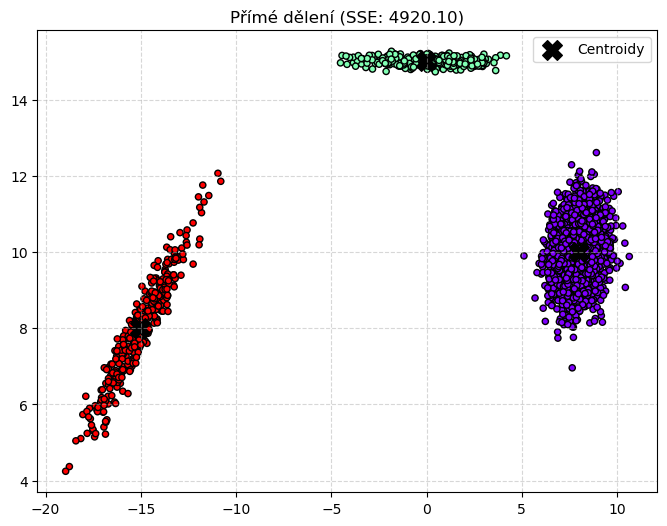

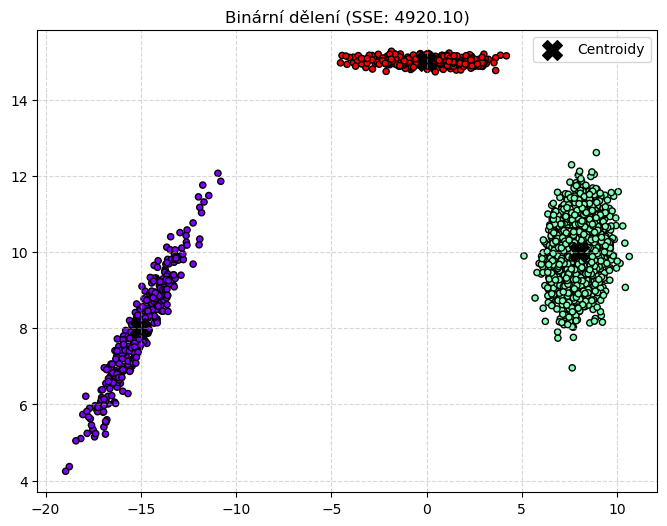

Srovnání SSE kvality:
-> Přímé dělení: 4920.10
-> Binární dělení: 4920.10


In [13]:
# Nastavíme seed pro replikovatelnost náhodného výběru u standard_kmeans
np.random.seed(42)

# 1. Přímé dělení (Direct K-means)
centroids_dir, labels_dir, sse_dir = cl.direct_partitioning(X, K_TARGET)
plot_clusters(X, labels_dir, f"Přímé dělení (SSE: {sse_dir:.2f})", centroids_dir)

# 2. Nerovnoměrné binární dělení (Bisecting K-means)
centroids_bis, labels_bis, sse_bis = cl.bisecting_kmeans(X, K_TARGET)
plot_clusters(X, labels_bis, f"Binární dělení (SSE: {sse_bis:.2f})", centroids_bis)

print(f"Srovnání SSE kvality:")
print(f"-> Přímé dělení: {sse_dir:.2f}")
print(f"-> Binární dělení: {sse_bis:.2f}")

Optimalizuji výsledek přímého dělení...


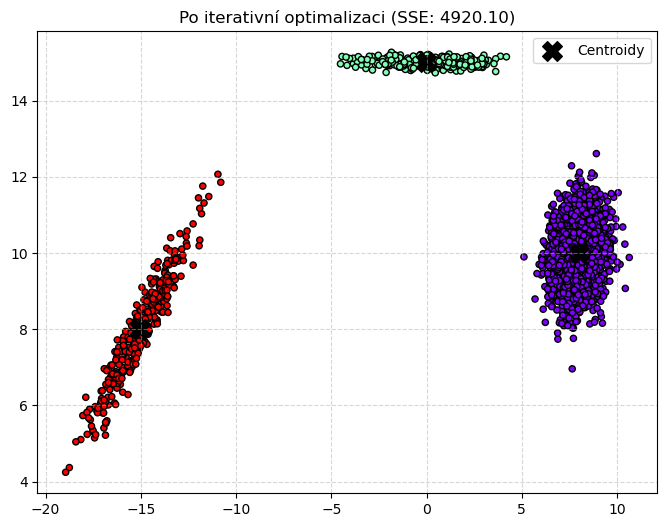


Zlepšení SSE po optimalizaci:
Původní SSE: 4920.10 -> Optimalizované SSE: 4920.10


In [12]:
print("Optimalizuji výsledek přímého dělení...")
opt_centroids, opt_labels = cl.iterative_optimization(X, labels_dir, K_TARGET)

# Přepočet výsledného SSE po optimalizaci
opt_sse = cl.calculate_sse(X, opt_centroids, opt_labels)

plot_clusters(X, opt_labels, f"Po iterativní optimalizaci (SSE: {opt_sse:.2f})", opt_centroids)

print(f"\nZlepšení SSE po optimalizaci:")
print(f"Původní SSE: {sse_dir:.2f} -> Optimalizované SSE: {opt_sse:.2f}")

### Vyhodnocení výsledků:
* **Přímé dělení (SSE: 4920.10):** Algoritmus úspěšně identifikoval tři přirozené shluky. Centroidy (označené černým křížkem) leží přesně v těžištích jednotlivých hustých oblastí.
* **Binární dělení (SSE: 4920.10):** Dosáhlo naprosto totožného rozdělení i identické hodnoty kritéria SSE. 
* **Iterativní optimalizace (SSE: 4920.10):** Spuštění iterativní optimalizace nad počátečním rozložením nevedlo k žádnému přesunu bodů (v konzoli se pravděpodobně neobjevily žádné zprávy o přesunech) a výsledné SSE zůstalo nezměněno.

### Diskuze a závěr:
Skutečnost, že všechny tři metody (včetně standardního K-means s náhodnou inicializací) dosáhly **shodného globálního minima (SSE = 4920.10)**, je způsobena specifickým charakterem datové sady. 

Vzhledem k tomu, že shluky jsou od sebe prostorově velmi vzdálené a husté, je konvergenční údolí pro správné řešení velmi hluboké a široké. Náhodná inicializace u přímého K-means tak téměř vždy spadne do správného (globálního) minima, což binární dělení i následná iterativní optimalizace pouze potvrdily jako stabilní a optimální stav.